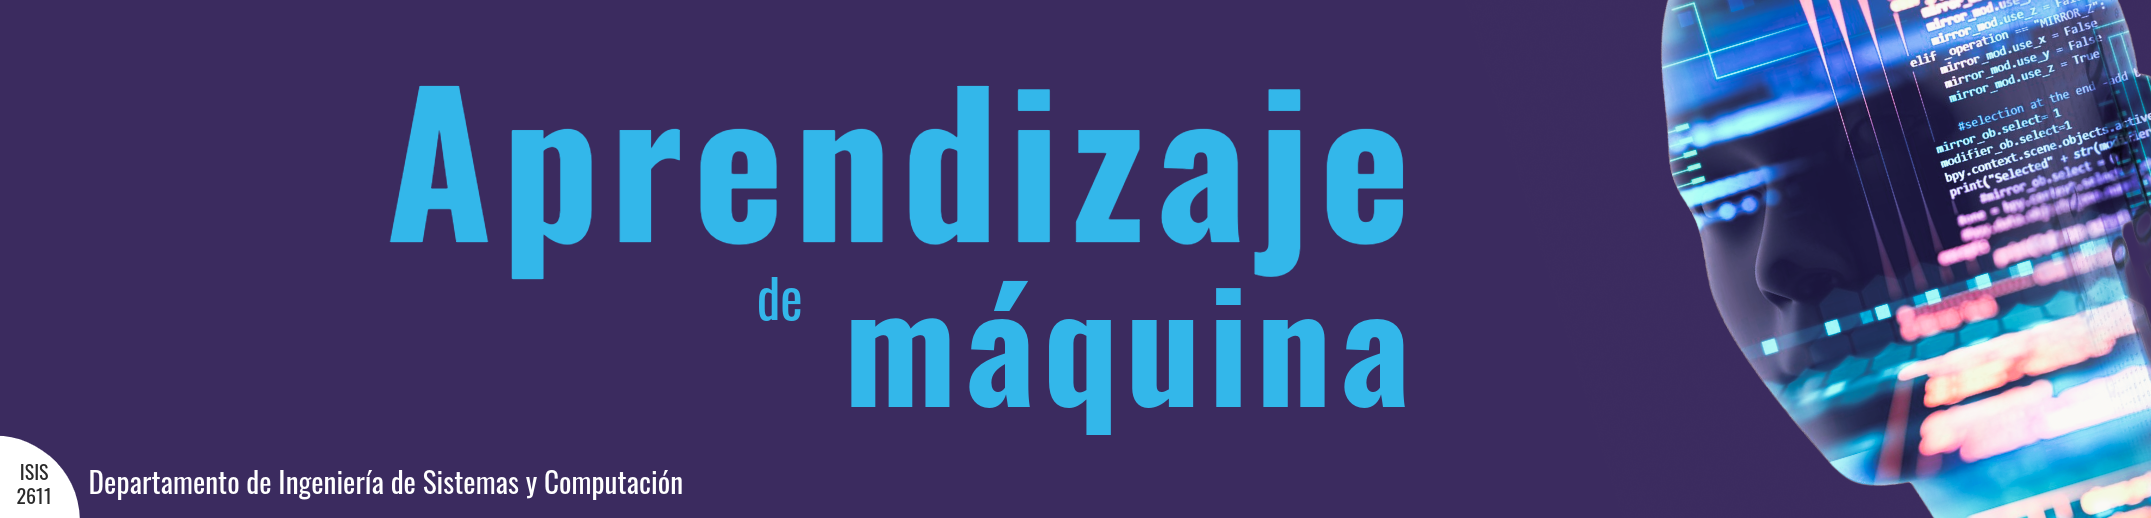


Estudiantes:

Camilo Molina – 202221119

Natalia Erazo – 202213680

# Laboratorio 1 - Exploración, preparación y regresión lineal

En este notebook se trabajará sobre el **Caso AlpesPlanck**:

El Instituto AlpesPlanck de Biogeoquímica registra variables meteorológicas cada 10 minutos en su estación de Jena, Alemania, desde 2003. Ellos han conocido el trabajo realizado por ustedes y están interesados en contratarlos para desarrollar un proyecto orientado a predecir la temperatura máxima de un día e identificar las variables metereológicas que más aportan a esa predicción, con el fin de diseñar estrategias que permitan mitigar problemas como incendios forestales o complicaciones relacionadas con fenómenos como "el Niño" o la "Niña".

Las actividades a realizar corresponden a: 
1. Exploración de los datos
2. Preparación de datos
3. Construcción de un modelo de regresión lineal
4. Evaluación cuantitativa
5. Evaluación cualitativa
6. Comunicar los resultados
7. Uso del modelo


## 1. Exploración de los datos

Como primer paso se importan las librerías con las que se va a trabajar. Además, se revisan las versiones de las librerías a usar para propósitos de documentación. El laboratorio se resuelve utilizando las siguientes versiones:

Versión de Pandas: 2.2.3

Versión de Matplotlib: 3.9.2

Versión de Seaborn: 0.13.2


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from importlib.metadata import version
print(f"Versión de Pandas: {version('pandas')}")
print(f"Versión de Matplotlib: {version('matplotlib')}")
print(f"Versión de Seaborn: {version('seaborn')}")

Versión de Pandas: 2.2.3
Versión de Matplotlib: 3.9.2
Versión de Seaborn: 0.13.2


### 1.1 Cargar del conjunto de datos

Se carga el archivo haciendo uso de la función read_csv().

In [7]:
datos_meteorologicos = pd.read_csv('./data/DatosLab1.csv', )

#copia de los datos
data = datos_meteorologicos.copy()

Para tener una primera visión de los datos usaremos la función head():

In [8]:
data.head()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.50,1000.87,1.3993,0.910860,0.875000,94.8,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0,2009.0,1.0,invierno,January,S,-2.12
1,2009-01-02,999.6006,997.93,1002.65,1.5039,0.920868,86.600000,96.3,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0,2009.0,2.0,invierno,JULY,NE,-0.82
2,2009-01-03,998.5486,993.05,1002.49,3.1304,76.458100,48.390000,93.9,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0,2009.0,3.0,invierno,January,SO,-0.63
3,2009-01-04,988.5107,985.12,992.93,2.3223,89.417400,97.946704,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0,2009.0,4.0,invierno,JANUARY,SO,-1.44
4,2009-01-05,990.4057,NaN,997.54,4.2315,86.260400,74.600000,93.2,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,2009.0,5.0,East,January,N,-10.88


> **Observación**: la validez en los datos de 'mes' no se cumple, según las 5 primeras filas: enero se representa como JANUARY y January.

### 1.2 Estructura del dataset

Para conocer el tamaño del conjunto de datos usamos la función `shape`:

In [16]:
data.shape

(2576, 27)

Esto nos dice que el conjunto de datos está compuesto por 2576 registros y 27 variables.

Para un primer acercamiento al tipo de dato de cada columna y al conteo de datos nulos usamos `data.info()`.

In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   object 
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 

> **Observación**: inicialmente se detectan valores nulos en múltiples columnas.

Identificamos las columnas específicas con valores nulos:

In [24]:
cols_con_null = []

for col in data.columns:
    if data[col].count() != len(data):
        cols_con_null.append(col)

print(cols_con_null)
print(len(cols_con_null))

['fecha', 'presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento', 'registros_del_dia', 'anio', 'dia_del_anio', 'estacion_anio', 'mes', 'sector_viento', 'temp_max_manana']
27


Se evidencia que en todas las 27 columnas hay datos nulos.

Ahora se explora el diccionario de datos:

In [20]:
dict = pd.read_excel('./data/DiccionarioDeDatos.xlsx')
pd.set_option('display.max_colwidth', None)
dict

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día (mbar).
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


Con el diccionario podemos entender el significado y rango válido de cada variable.

Se intuye:

- 'anio', 'mes' y 'dia_del_anio' deben coincidir con los datos de la columna 'fecha'.

- los datos de [varible]_media den ser mayores a [varible]_min y menores a [varible]_max.

- la estacion_anio debe coincidir con la fecha (hemisferio norte por Jena, Alemania).


Ahora clasificamos las columnas según su tipo estadístico:

In [25]:
# Clasificamos las columnas según su tipo estadístico
# basándonos en el diccionario de datos y el contexto del problema

cuantitativas_continuas = ['presion_media', 'presion_min', 'presion_max', 'presion_desv',
                           'humedad_media', 'humedad_min', 'humedad_max','humedad_desv',
                           'viento_media', 'viento_min', 'viento_max','viento_desv',
                           'rafaga_media', 'rafaga_min', 'rafaga_max','rafaga_desv',
                           'viento_norte', 'viento_este',
                           'direccion_viento']
cuantitativas_discretas = ['registros_del_dia', 'anio', 'dia_del_anio']
cualitativas_ordinales  = []
cualitativas_nominales  = ['estacion_anio', 'sector_viento', 'mes']



print("Cuantitativas continuas :", cuantitativas_continuas)
print("Cuantitativas discretas :", cuantitativas_discretas)
print("Cualitativas ordinales  :", cualitativas_ordinales)
print("Cualitativas nominales  :", cualitativas_nominales)

Cuantitativas continuas : ['presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'viento_norte', 'viento_este', 'direccion_viento']
Cuantitativas discretas : ['registros_del_dia', 'anio', 'dia_del_anio']
Cualitativas ordinales  : []
Cualitativas nominales  : ['estacion_anio', 'sector_viento', 'mes']


### 1.3 Descripción de los datos
Para obtener mediciones estadísticas (como la media, la desviación estándar, el mínimo, el máximo y una separación por cuartiles) y una descripción más clara de los datos usamos la función `describe()`.


In [27]:
data.describe()

,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,viento_min,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2501.000000,2502.000000,2512.000000,2496.000000,2502.000000,2496.000000,2490.000000,2515.000000,2490.000000,2485.000000,...,2504.000000,2503.000000,2497.000000,2496.000000,2512.000000,2497.000000,2499.000000,2490.000000,2508.000000,2481.000000
mean,1010.494271,986.684409,991.704244,1.752041,52.413586,45.094067,90.236582,10.606821,3.814103,1.417799,...,-2.639322,6.946058,-5.763253,-1.128463,-0.410159,172.104573,144.090836,2011.995582,182.690989,13.863309
std,435.334494,8.927138,7.726906,1.215931,35.975384,30.196163,10.647237,5.481338,3.307402,3.960650,...,199.861693,3.237379,75.258134,25.065084,1.147218,86.102348,4.107365,1.999694,105.529469,9.296199
min,948.996000,913.600000,951.940000,0.226900,0.004663,0.237700,27.020000,0.000000,0.000000,0.000000,...,-9999.000000,0.000000,-232.260000,-1250.463300,-3.718500,0.000000,90.000000,2009.000000,1.000000,-15.230000
25%,984.287800,981.371333,987.070000,0.899050,0.869060,1.011790,88.025000,6.082100,1.655350,0.230000,...,0.440000,4.803198,1.002100,-1.640625,-1.236475,91.303500,144.000000,2010.000000,91.000000,7.310000
50%,989.452800,987.070000,991.935000,1.444550,68.558100,49.670000,93.300000,10.199800,2.463400,0.440000,...,0.660000,6.690000,1.461100,-0.564300,-0.356000,199.568500,144.000000,2012.000000,182.500000,14.310000
75%,994.469000,992.567500,996.782500,2.254800,80.562600,67.665000,96.600000,14.722200,4.880505,0.960000,...,1.120000,8.850000,2.008800,0.241525,0.316275,227.101700,144.000000,2014.000000,274.250000,20.460000
max,9939.918000,1012.320198,1013.940000,12.397500,100.000000,103.311405,100.000000,26.341600,24.753600,45.184956,...,19.895916,23.500000,3471.027800,4.809900,4.713900,359.796700,287.000000,2015.000000,366.000000,63.050000


#### Descripción de variables cualitativas

Usamos `describe()` con el parámetro `include='object'` para estudiar las variables de tipo `object` (categóricas / texto).

Esto nos devuelve:

- `count`: valores no nulos.
- `unique`: cuántos valores distintos existen.
- `top`: valor más frecuente (moda).
- `freq`: cuántas veces aparece ese valor.

> **Observaciones**:
> - Encontramos problemas de válidez para estacion_anio pues hay 28 valores posibles y solo deberían ser 4.
> - Encontramos problemas de válidez para mes pues hay 61 valores posibles y solo deberían ser 12.
> - Encontramos problemas de válidez para sector_viento pues hay 33 valores posibles y solo deberían ser 8.


In [34]:
# Descripción de columnas cualitativas (tipo object)
data.describe(include='object')

,fecha,estacion_anio,mes,sector_viento
count,2504,2488,2488,2505
unique,2486,28,61,33
top,2010-08-14,primavera,May,SO
freq,2,517,127,695


In [46]:
# Revisar formatos para ver cuántas representaciones diferentes de los mismos datos hay y cuáles son...

objetos = ['estacion_anio', 'mes', 'sector_viento'
] 

for i in objetos:
    print("Valores únicos en " + i + ":")
    print(data[i].unique())
    print(f"Total de valores únicos: {data[i].nunique()} \n\n")

Valores únicos en estacion_anio:
['invierno' 'East' nan 'Estacion_Desconocida' 'verano' 'Inverano'
 'invierno ' 'INVIERNO' 'VERANO_INVIERNO' 'Verano' 'primavera' 'Primavera'
 'primaveraa' 'PRIMAVERA' 'berano' 'VERANO' 'verno' 'otono' 'otoño '
 'fall' 'autumn' 'OTONO' 'winter' 'invernio' 'primav' 'spring' 'Otoño'
 'Invierno' 'summer']
Total de valores únicos: 28 


Valores únicos en mes:
['January' 'JULY' 'JANUARY' 'May' 'Enero' nan 'JUNE' 'Sep' 'April'
 'SEPTEMBER' 'noviembre' 'octubre' 'Sept' 'november' 'april' 'julio'
 'February' 'APRIL' 'Aug' 'febrero' 'septiembre' 'Mar' 'Nov' 'MARCH'
 'february' 'November' 'may' 'july' 'august' 'september' 'July' 'March'
 'October' 'junio' 'october' 'march' 'marzo' 'September' 'Oct' 'DECEMBER'
 'Jan' 'enero' 'NOVEMBER' 'december' 'Jul' 'OCTOBER' 'Jun' 'diciembre'
 'AUGUST' 'June' 'january' 'june' 'Feb' 'August' 'December' 'agosto' 'Apr'
 'mayo' 'abril' 'FEBRUARY' 'MAY' 'Dec']
Total de valores únicos: 61 


Valores únicos en sector_viento:
['S' 'NE'

Para conocer el número de veces que cada valor aparece en una las columnas, usamos la función `value_counts()`:


In [42]:
for i in objetos:
    display(data[i].value_counts())

estacion_anio
primavera               517
invierno                511
otono                   500
verano                  487
Inverano                 71
Estacion_Desconocida     63
VERANO_INVIERNO          60
East                     48
VERANO                   19
autumn                   18
primaveraa               17
berano                   17
fall                     15
winter                   15
verno                    14
Otoño                    12
otoño                    11
invernio                 11
PRIMAVERA                10
Primavera                10
Invierno                  9
Verano                    9
invierno                  9
INVIERNO                  9
OTONO                     8
primav                    6
spring                    6
summer                    6
Name: count, dtype: int64

mes
May           127
August        125
July          123
January       120
March         118
             ... 
septiembre     16
april          16
junio          16
OCTOBER        13
Jan            13
Name: count, Length: 61, dtype: int64

sector_viento
SO           695
S            519
NE           424
O            308
N            124
E             77
SE            66
NO            42
Suroeste      29
so            26
SOUTHWEST     24
s             20
ne            19
South         19
NORTHEAST     17
Sur           16
Noreste       12
SOUTH          8
o              8
no             6
NORTH          6
West           5
WEST           5
EAST           4
North          4
East           4
SOUTHEAST      3
Sureste        3
Oeste          3
Noroeste       3
Norte          3
Este           2
NORTHWEST      1
Name: count, dtype: int64

### 1.4 Datos duplicados

Revisamos cuántas filas de datos se encuentran totalmente duplicadas:

In [54]:
display(data.duplicated().sum())

display(data[data.duplicated(keep=False)])

np.int64(4)

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
21,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.11,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770
1412,2012-11-13,1005.3724,1002.77,1006.81,1.0690,88.175500,58.28,99.1,12.6853,4.07916,...,-0.9230,-0.2193,193.3681,144.0,2012.0,318.0,otono,abril,S,44.852
1499,2013-02-08,984.6369,983.06,987.49,1.3454,0.886056,0.76,96.8,4.6160,NaN,...,0.0254,-0.2613,275.5529,144.0,2013.0,39.0,verano,Sep,O,-0.600
1570,2013-04-20,1000.4455,998.46,1002.49,1.1632,60.748100,45.71,82.0,10.9518,17.65908,...,4.1573,2.5121,31.1426,144.0,2013.0,110.0,primavera,JANUARY,NE,61.412
2556,2013-04-20,1000.4455,998.46,1002.49,1.1632,60.748100,45.71,82.0,10.9518,17.65908,...,4.1573,2.5121,31.1426,144.0,2013.0,110.0,primavera,JANUARY,NE,61.412
2559,2012-11-13,1005.3724,1002.77,1006.81,1.0690,88.175500,58.28,99.1,12.6853,4.07916,...,-0.9230,-0.2193,193.3681,144.0,2012.0,318.0,otono,abril,S,44.852
2563,2009-01-22,9784.1150,971.48,983.54,3.9853,86.731100,69.11,97.6,9.7926,10.09692,...,-2.7229,-0.1899,183.9897,144.0,2009.0,22.0,verano,octubre,S,5.770
2565,2013-02-08,984.6369,983.06,987.49,1.3454,0.886056,0.76,96.8,4.6160,NaN,...,0.0254,-0.2613,275.5529,144.0,2013.0,39.0,verano,Sep,O,-0.600


> **Observación**: Se detectan **4 filas completamente duplicadas** que serán eliminadas en la fase de preparación.

### 1.5 Visualización de variables

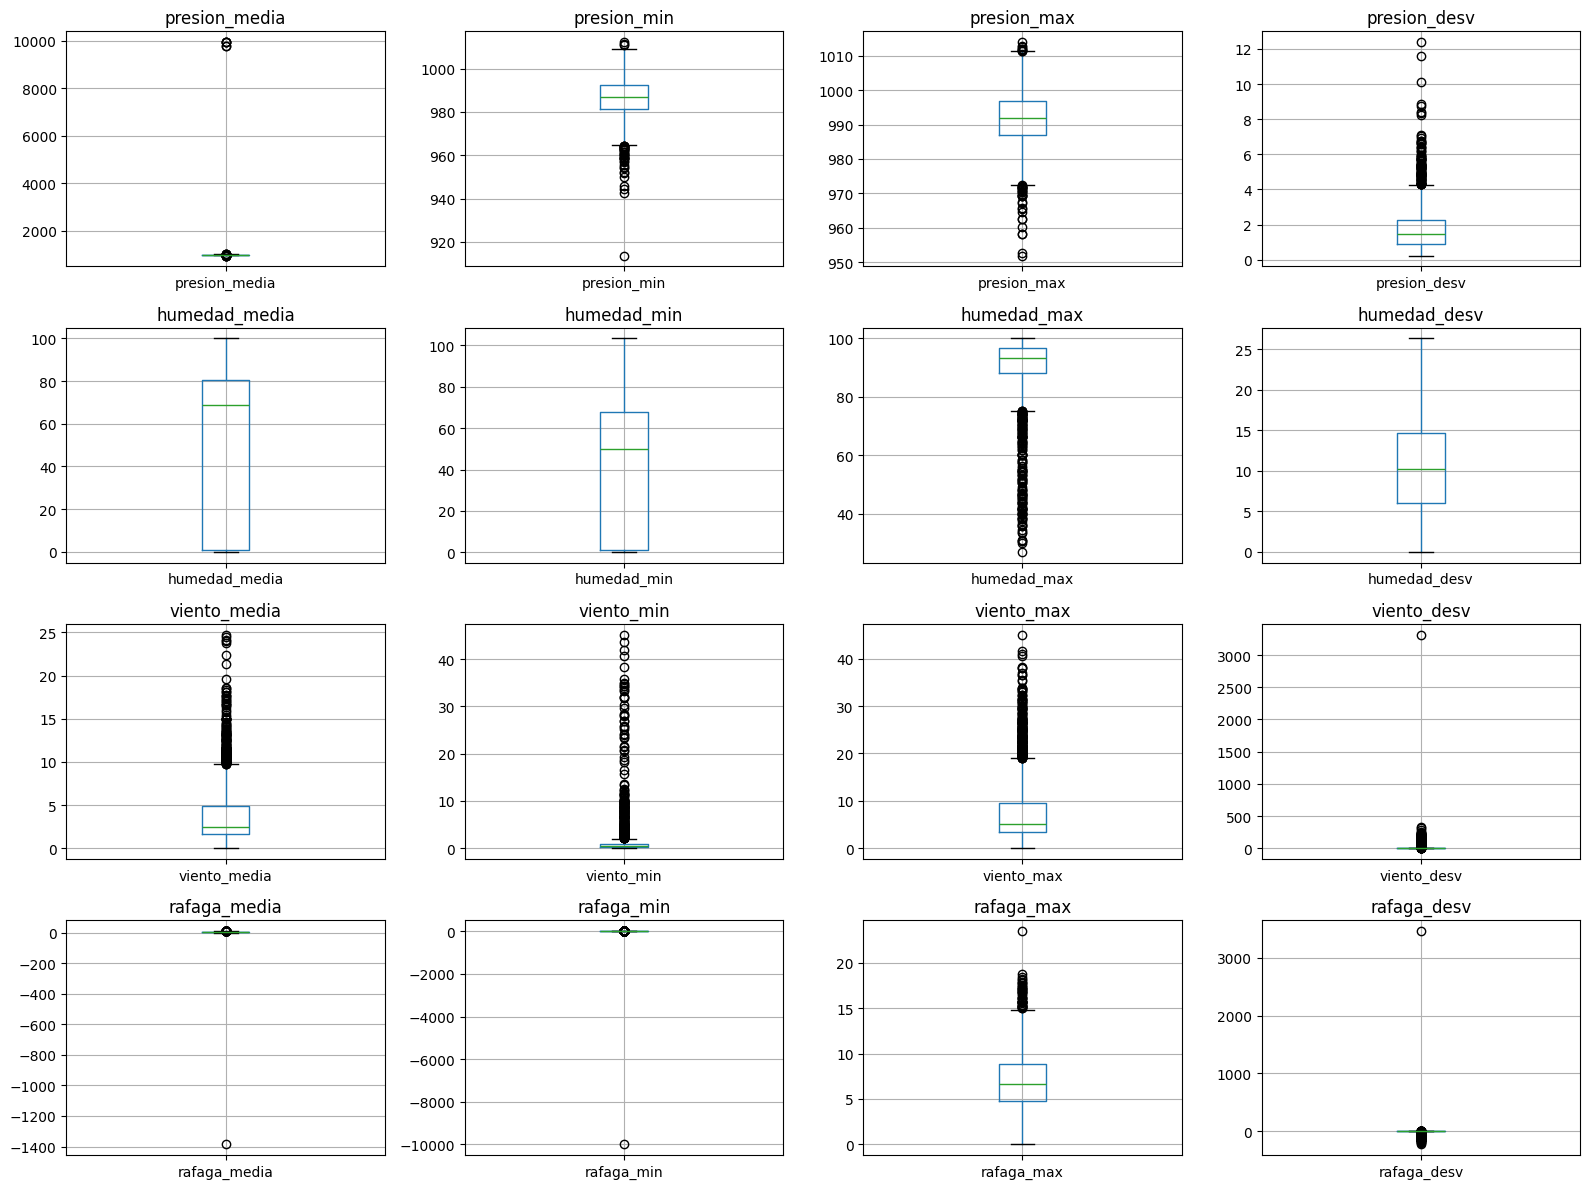

In [55]:
# Se incluyen unicamente variables numericas para los boxplots
numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        data.boxplot(column=col, ax=axes[i])
        axes[i].set_title(col)

plt.tight_layout()
plt.show()

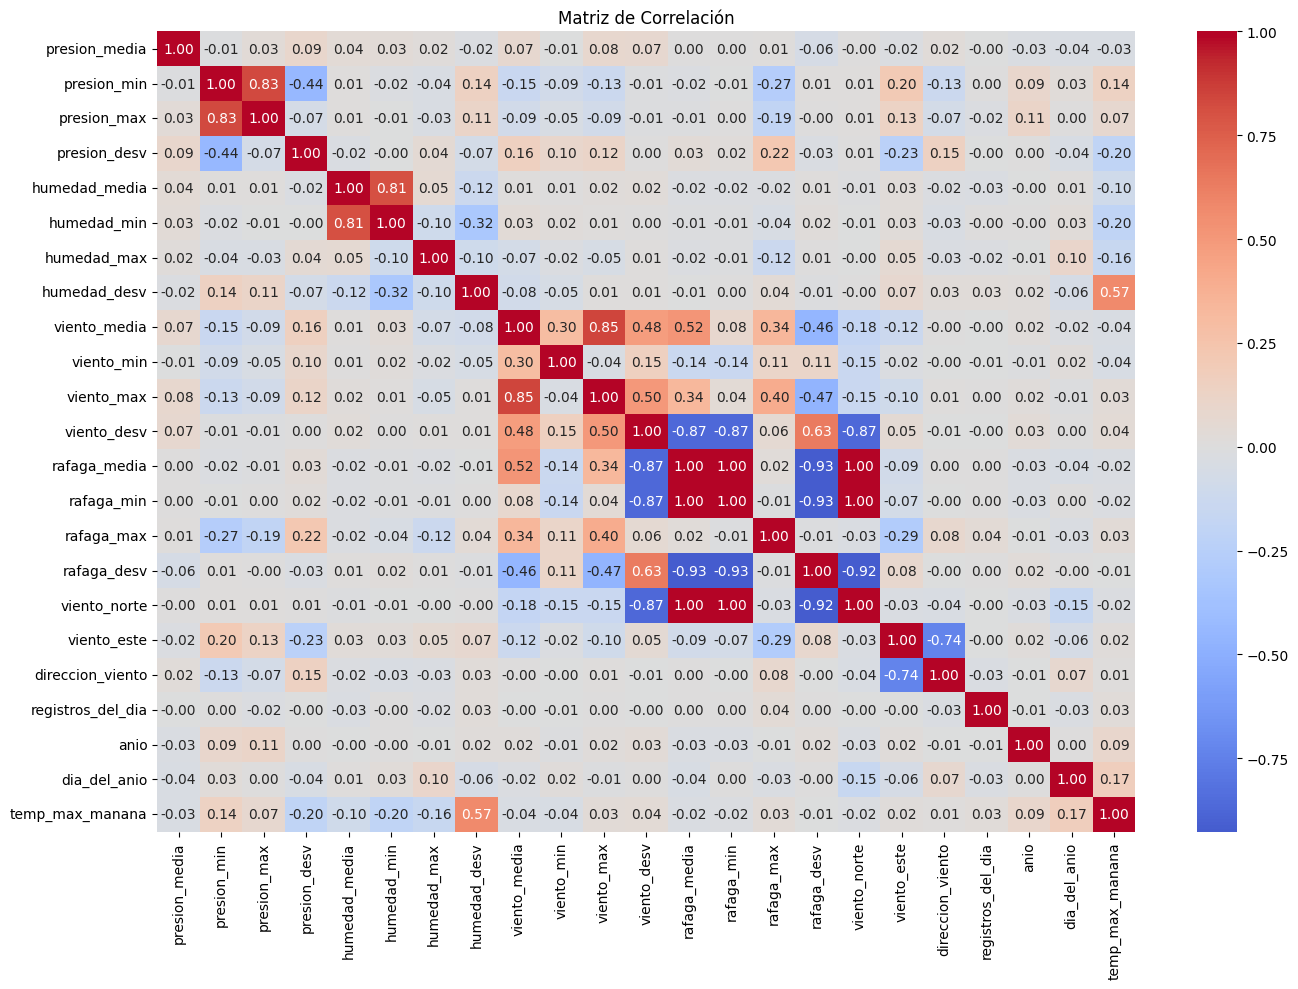

In [56]:
plt.figure(figsize=(14, 10))
sns.heatmap(data[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

## 5. Exploración con distintos tipos de visualizaciones.

De momento solo hemos explorado los datos a través de estructuras, todas las conclusiones que hemos obtenido hasta el momento son gracias a la interpretación de una lista o tabla. También solo hemos trabajado una de las librerías que importamos al inicio `Pandas`. Pero ahora, vamos a profundizar más la exploración de los datos a través de visualizaciones, para ello pasaremos a usar las librerías que importamos `Matplotlib` y `Seaborn`. Antes de crear cada gráfico es útil conocer para qué sirve el tipo de gráfico, cuándo usarlo y cuál tipo de variable visualiza:

| **Tipo de gráfico** | **¿Cuándo usarlo?** | **Tipo de variables** |
|:--------------------|:--------------------|:----------------------|
| **Barras** | Comparar frecuencias o totales<br>entre categorías. | Una variable cualitativa (nominal u ordinal)<br>o cuantitativa discreta. |
| **Histograma** | Visualizar la distribución<br>de una variable. | Una variable cuantitativa continua. |
| **Dispersión (scatter plot)** | Explorar la relación entre dos variables numéricas<br>e identificar patrones, tendencias o agrupamientos. | Dos variables cuantitativas. |
| **Pie (gráfico circular)** | Mostrar la proporción de cada categoría<br>cuando existen pocas categorías. | Una variable cualitativa (nominal). |
| **Boxplot (diagrama de caja)** | Resumir la distribución de una variable<br>e identificar posibles valores atípicos.<br>También permite comparar distribuciones entre grupos. | Una variable cuantitativa o una variable cuantitativa<br>agrupada por una variable cualitativa. |
| **Joint plot** | Analizar simultáneamente la relación entre dos variables<br>y sus distribuciones marginales. | Dos variables cuantitativas. |


### Matplotlib

Matplotlib es la librería base de visualización en Python. Las funciones básicas que usaremos son:
- `figure(figsize=(...))`: crea una nueva figura con el tamaño indicado en pulgadas.
- `xlabel()` / `ylabel()` / `title()`: etiquetas de los ejes y título.
- `show()`: renderiza el gráfico.

Para entender cómo se construye cada gráfico con Matplotlib, es importante conocer el papel de cada función:

- `bar(x, y)`: gráfico de barras. `x` son las categorías, `y` las alturas.
- `hist(x, bins=N)`: histograma. `bins` define en cuántos intervalos se agrupan los datos.
- `plot(x, y, fmt)`: gráfico de líneas o puntos. `fmt` define el estilo: `'.'` puntos, `'-'` línea, `'o'` círculos.
- `pie(valores, labels=..., autopct=...)`: gráfico de torta. `autopct` muestra el porcentaje de cada sector.

#### Gráfico de barras — distribución de años de construcción

Un gráfico de barras es apropiado aquí porque `Años` es una variable cuantitativa discreta: tiene valores enteros y queremos contar cuántos inmuebles se construyeron en cada año.

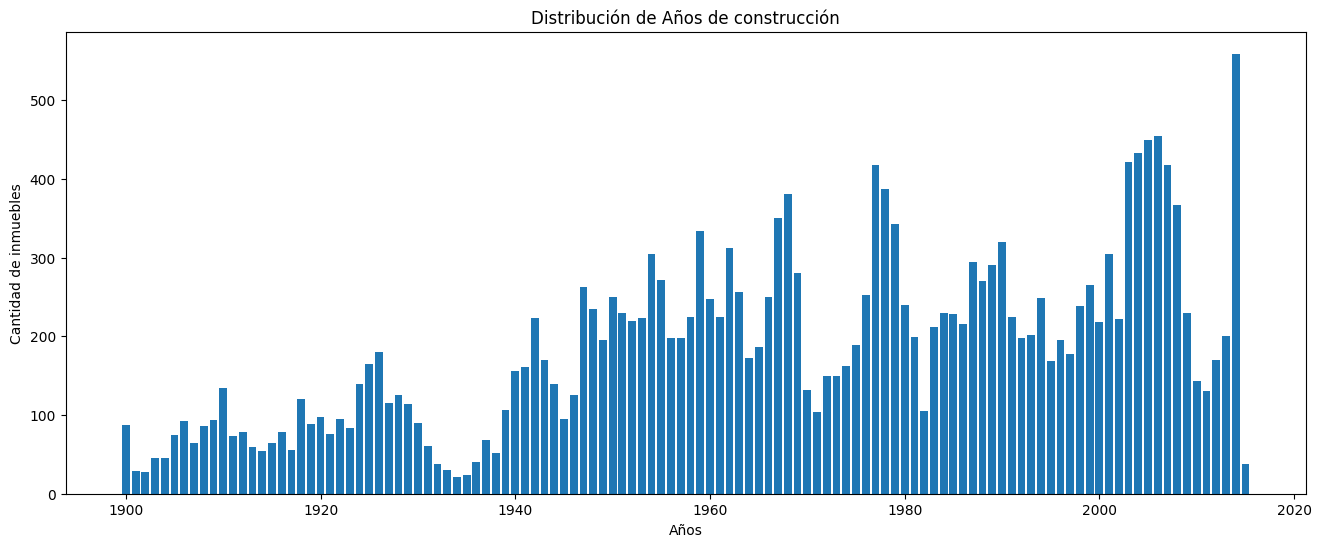

In [27]:
# Tamaño de la gráfica
plt.figure(figsize=(16,6))

# Cantidad de apariciones de cada año de construcción
plot_data = data['Años'].value_counts()

# Valores únicos (años) y sus frecuencias
x = plot_data.index
y = plot_data.values

# Gráfico de barras
plt.bar(x,y)

# Títulos de los ejes y del gráfico
plt.xlabel("Años")
plt.ylabel("Cantidad de inmuebles")
plt.title('Distribución de Años de construcción')

# Mostrar la gráfica
plt.show()

Esta gráfica muestra la distribución de los años de construcción de inmuebles. En el eje X se muestran los años en que fueron construidas, mientras que en el eje Y se observa la cantidad de casas que se construyeron en cada año. De esta forma podemos identificar patrones, como los periodos en donde se tuvo un aumento en la construcción o los años en donde se tuvieron menores edificaciones.

Adicionalmente, podemos crear otros tipos de gráficos, como **histogramas**, que muestran la frecuencia de aparición de valores numéricos dentro de intervalos continuos. Este gráfico nos ayuda a analizar la distribución de una variable.

Para ello, usamos la siguiente función adicional a las mencionadas anteriormente:

* `hist()`: Esta función establece que se renderizará un histograma, como parámetro usa la variable a graficar y el número de intervalos (bins) en los que se dividirán los datos.

#### Histograma — distribución de precios

El histograma es apropiado para `Precio` porque es una variable cuantitativa **continua**: agrupa valores en intervalos (`bins`) y muestra la frecuencia de cada intervalo.

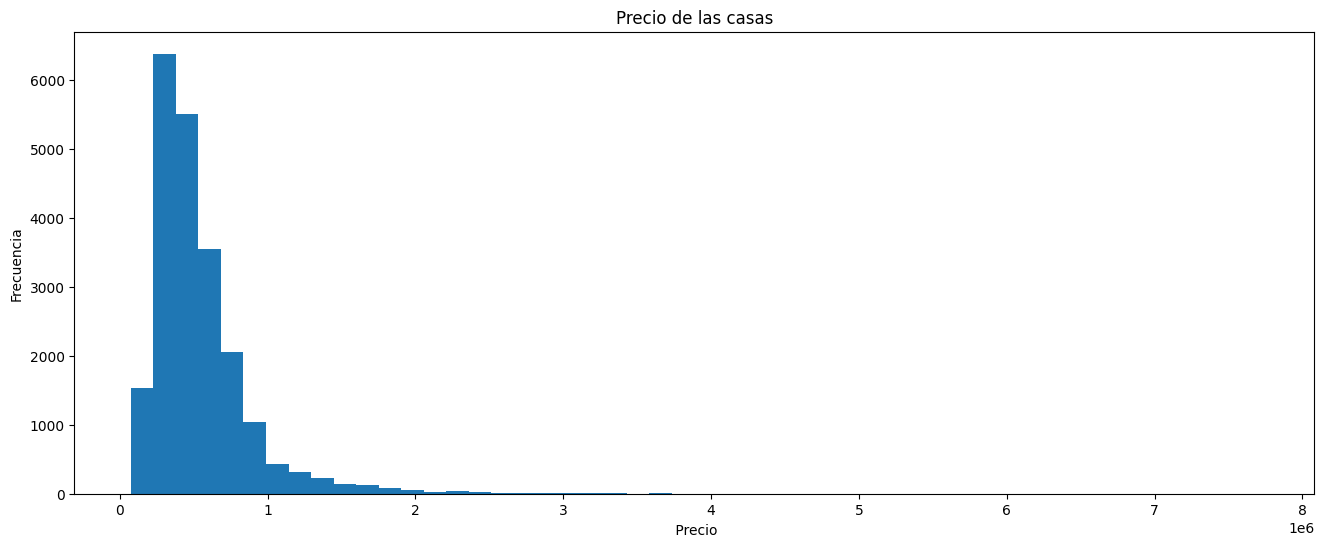

In [28]:
# Tamaño de la gráfica
plt.figure(figsize=(16,6))

# Variable a graficar
x = data['Precio']

# Histograma
plt.hist(x, bins=50)

# Títulos de los ejes y de la gráfica
plt.xlabel(" Precio")
plt.ylabel("Frecuencia")
plt.title('Precio de las casas')

# Mostrar gráfica
plt.show()

Este histograma muestra la distribución de los precios de las casas. En el eje X tenemos los valores de precio (que están divididos en 50 intervalos y cuya escala es en millones), mientras que en el eje Y se encuentra la frecuencia con la que aparecen los precios en el conjunto de datos. Este gráfico nos ayuda a entender que la mayor parte de las casas se encuentra en un precio inferior a un millón.

Otra gráfica que ofrece esta librería es de **líneas o puntos**, que nos permite observar relaciones entre dos variables. Por ejemplo, analizaremos la relación entre el número de baños y el precio. La función `plot()` recibe estos argumentos:

* `data['Baños]`: Los datos que tendrá el eje X.
* `data['Precio]`: Los datos que incluirá el eje Y.
* `.`: Establece el formato a usarse, en este caso de puntos. Pero también se pueden usar otros, como `*` para estrellas o `o` para círculos.
* `color='blue'`: Color que tendrá la gráfica.





#### Gráfico de dispersión — relación entre dos variables numéricas

Este tipo de gráfico muestra la relación entre dos variables cuantitativas. Cada punto representa un inmueble; su posición en X e Y indica los valores de las dos variables elegidas.

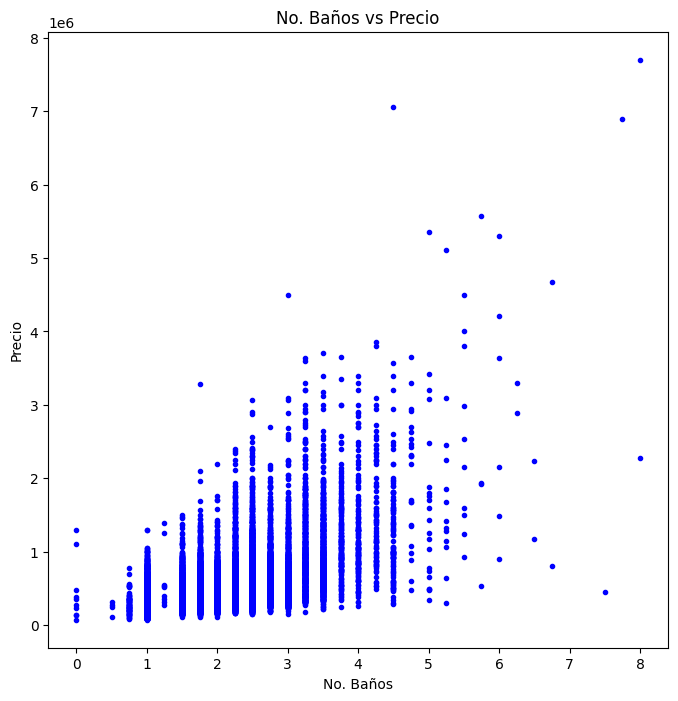

In [29]:
plt.figure(figsize=(8,8))

x = data['Baños']
y = data['Precio']

plt.plot(x, y, '.', color='blue')
plt.title('No. Baños vs Precio')
plt.xlabel('No. Baños')
plt.ylabel('Precio')
plt.show()

Este gráfico nos permite ver una tendencia, la cual es que a medida que aumenta el número de baños, el precio tiende a ser mayor. Sin embargo, la dispersión es considerable lo que nos da a entender que el número de baños no es el único factor determinante, sino que existen otros factores que también influenciaron en el precio.

Matplotlib también nos permite realizar gráficos de **pie**, los cuales permiten representar la proporción de cada categoría dentro de un conjunto de datos. Cada región del círculo corresponde a una categoría distinta y su tamaño refleja el porcentaje que ocupa respecto al total. Para realizar este gráfico necesitamos la función `pie()` que es la encargada de generar el gráfico circular. Sus parámetros principales son:

* `Valores numéricos`: Indican el tamaño de cada sector (por ejemplo, la frecuencia de cada categoría).
* `labels`: Define las etiquetas que se mostrarán en cada sector (por ejemplo, el número de habitaciones).
+ `autopct`: Muestra el porcentaje que representa cada categoría respecto al total.



#### Gráfico de torta — proporciones de una variable categórica

El gráfico de torta es adecuado para variables nominales con pocas categorías. Muestra qué proporción del total corresponde a cada categoría. En nuetro conjunto de datos solo tenemos FrenteMar.

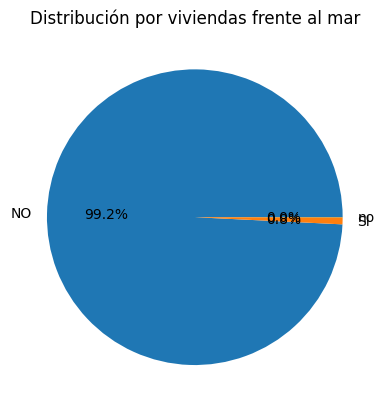

In [30]:
# Obtener el número de valores de cada categoría
categorias_count = data['FrenteMar'].value_counts()#.head(5)

# Función para ilustrar en forma de pie
plt.pie(categorias_count, labels=categorias_count.index, autopct='%1.1f%%')

# Título
plt.title('Distribución por viviendas frente al mar')

# Mostrar
plt.show()

Ten en cuenta que, aunque un pie puede utilizarse para variables con pocas categorías, no es recomendable cuando una de ellas representa una proporción muy pequeña del total. En estos casos, un gráfico de barras facilita la comparación y la lectura de las frecuencias.

#### Ejercicio

CConstruye un gráfico de barras que muestre el número promedio de cuartos para cada número de pisos de la vivienda. Para lograrlo necesitarás:
1. Agrupar el DataFrame por `Pisos` y calcular el promedio de `Cuartos` en cada grupo (pista: `groupby` + `mean()`).
2. Crear la figura con `plt.figure()`.
3. Dibujar las barras con `plt.bar()`, usando los valores de piso como eje X y el promedio de cuartos como altura.
4. Agregar título y etiquetas de ejes.
5. Mostrar el gráfico con `plt.show()`.

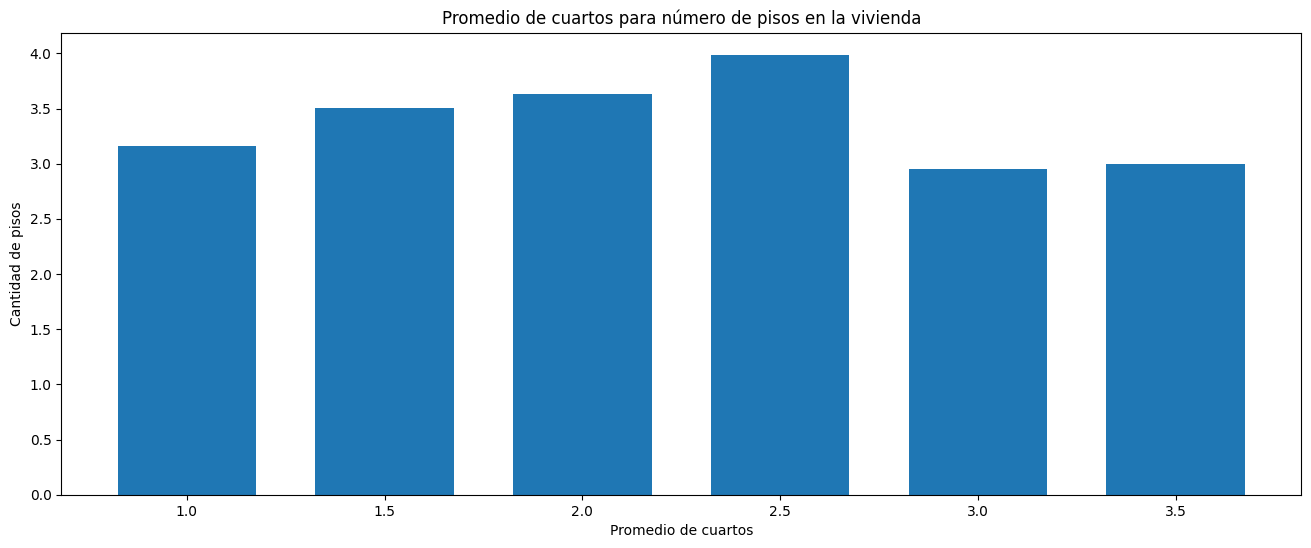

In [31]:
# TODO: Agrupa por 'Pisos' y calcula el promedio de 'Cuartos'
dataPisos = data.groupby('Pisos')
dataProm = dataPisos['Cuartos'].mean()

# TODO: Crea una nueva figura
plt.figure(figsize=(16,6))

# TODO: Dibuja las barras usando el índice como categorías y los valores como alturas
x = dataProm.index
y = dataProm.values

plt.bar(x, y, width=0.35)

# TODO: Agrega un título diciente para el gráfico
plt.title('Promedio de cuartos para número de pisos en la vivienda')

# TODO: Nombra los ejes
plt.xlabel("Promedio de cuartos")
plt.ylabel("Cantidad de pisos")

# TODO: Muestra el gráfico.
plt.show()




### Seaborn

Al igual que con Matplotlib, la librería Seaborn también nos ayuda a crear visualizaciones para entender mejor nuestro dataset. Para crear un **histograma** necesitamos la función `histplot()`, que requiere de estos parámetros:

* `data[Precio]`: Datos ubicados en el eje X.
* `kde=True`: Este argumento permite dibujar una curva para comprender mejor la distribución de la variable.


Seaborn es una librería de visualización construida sobre Matplotlib que ofrece gráficos estadísticos más elaborados con menos código. Sus principales ventajas son la integración directa con DataFrames de Pandas y la generación automática de curvas de densidad.

#### Histograma con curva de densidad (KDE)

`histplot()` es la versión Seaborn del histograma. El parámetro `kde=True` superpone una curva de estimación de densidad de kernel (KDE), que suaviza la distribución y facilita identificar la forma general (simétrica, sesgada a la derecha, bimodal, etc.).

<Axes: title={'center': 'Distribución del precio de las casas'}, xlabel=' Precio', ylabel='Frecuencia'>

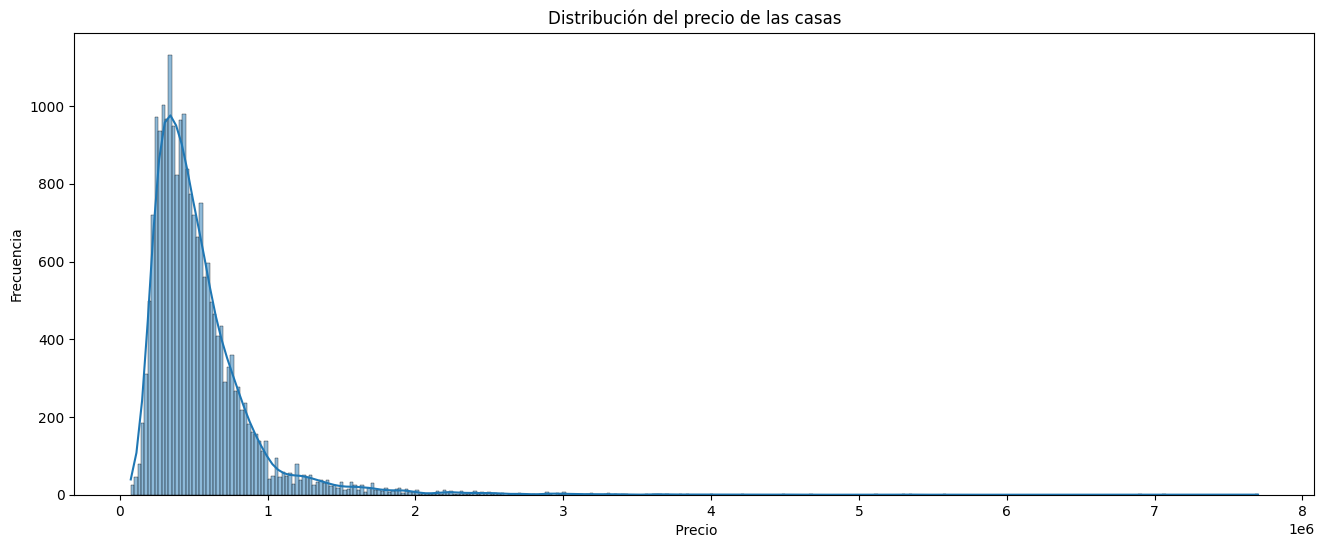

In [32]:
# Crear gráfica con esas dimensiones
plt.figure(figsize=(16,6))

# Datos a usar
x = data['Precio']

# Título
plt.xlabel(" Precio")
plt.ylabel("Frecuencia")
plt.title('Distribución del precio de las casas')

# Histograma
sns.histplot(x=data['Precio'], kde=True)

Podemos ver que obtuvimos una gráfica bastante similar a la que teníamos anteriormente con Matplotlib, solo que esta no está tan agrupada como esa. En caso de que quisiéramos que la gráfica fuera exactamente igual, solo deberíamos agregar un tercer parámetro a la función: `histplot` que sería `bins=50`, que referencia a los intervalos en los que queremos que se agrupen los datos.

#### Boxplot — distribución y valores atípicos

El **boxplot** (diagrama de caja) es ideal para visualizar la distribución de una variable cuantitativa continua y detectar valores atípicos (*outliers*). Su estructura es:

- **Caja**: abarca del cuartil Q1 al Q3 (el 50% central de los datos).
- **Línea interior**: mediana (Q2).
- **Bigotes**: se extienden hasta 1.5 × IQR desde la caja (IQR = Q3 − Q1).
- **Puntos fuera de los bigotes**: valores atípicos estadísticos.

<Axes: xlabel='AreaHabitable'>

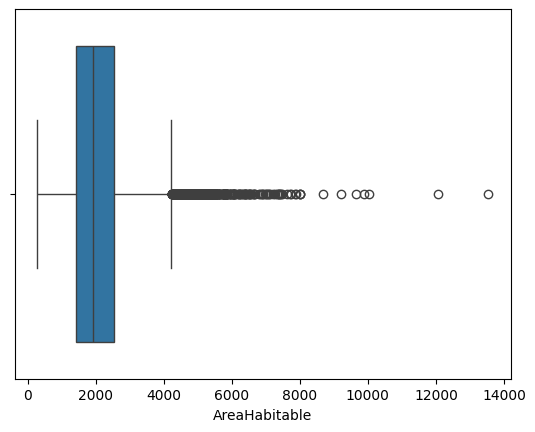

In [33]:
sns.boxplot(x=data['AreaHabitable'])

 La gráfica muestra un boxplot en donde la mayoría de las propiedades tienen un tamaño entre aproximadamente 1.400 y 2.500 pies cuadrados. La gráfica también permite ver que tiene una mediana cercana a 2.000 pies cuadrados. Otra observación importante es resaltar
 la gran cantidad de outliers extremos que superan los 4,000 pies cuadrados, llegando incluso a valores cercanos a 14.000 pies cuadrados. Esto indica que el dataset contiene propiedades atípicas (mansiones o haciendas) que podrían influir significativamente en análisis.

 Otra gráfica que podemos a utilizar es la de **JointGrid**, la cual combina un gráfico en el centro que muestra la relación entre dos variables con histogramas en los ejes, este permite ver la correlación entre dos variables como sus distribuciones. Lo cual resulta útil para analizar las concentraciones y los patrones que los datos muestran. La función que se usa es: `jointgrid()`.

#### JointGrid — relación entre dos variables con distribuciones marginales

El `JointGrid` combina en una sola figura:
- **Gráfico central**: muestra la relación conjunta entre dos variables (aquí como mapa de densidad).
- **Histogramas marginales** en los bordes: muestran la distribución individual de cada variable.

Es útil para explorar simultáneamente correlación y distribución.

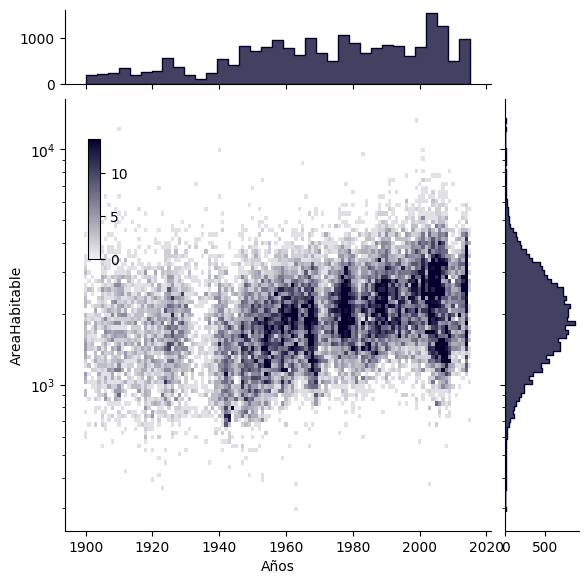

In [34]:
# Cargar los datos
g = sns.JointGrid(data=data, x="Años", y="AreaHabitable", marginal_ticks=True)

# Escala logaritmica
g.ax_joint.set(yscale="log")

# Leyenda para la barra de colores
cax = g.figure.add_axes([.15, .55, .02, .2])

# Agregar histograma articular y marginal
g.plot_joint(
    sns.histplot, discrete=(True, False),
    cmap="light:#03012d", pmax=.8, cbar=True, cbar_ax=cax
)
g.plot_marginals(sns.histplot, element="step", color="#03012d")

En el gráfico central, los colores indican la densidad de puntos, en donde las zonas más oscuras representan áreas con mayor concentración. Se observa que las casas más recientes tiendes a ser más grandes, ya que antes de 1960 predominan las áreas más pequeñas, mientras que después de la década de los 80s se tienen construcciones con áreas mayores. Mientras que también se puede observar que después del 2000, las áreas empiezan a bajar como generalidad, aunque también hay que mencionar que durante ese periodo se tienen datos con mayor área.

#### **Ejercicio**

Crea un **boxplot** que muestre la distribución de `Precio` agrupada por número de `Pisos`. Esto te permitirá ver si los inmuebles con más pisos tienden a tener precios más altos y qué tan dispersos son esos precios.

Para boxplot de Seaborn con dos variables usa: `sns.boxplot(x='variable_categorica', y='variable_numerica', data=df)`.

Text(0, 0.5, 'Precio')

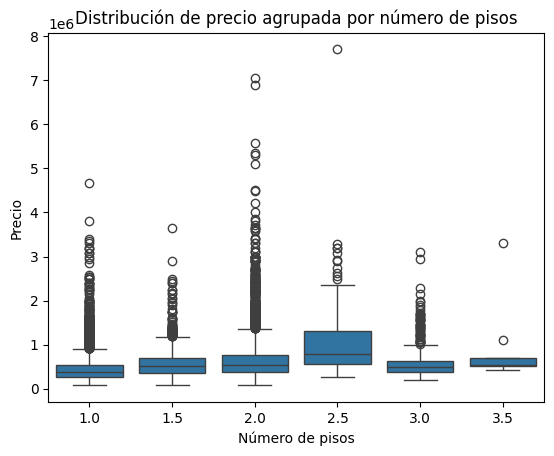

In [35]:
# TODO: Función boxplot con los datos de los ejes
sns.boxplot(x='Pisos', y='Precio', data=data)

# TODO: Título de la visualización
plt.title('Distribución de precio agrupada por número de pisos')

# TODO: Nombre del eje X
plt.xlabel('Número de pisos')

# TODO: Nombre del eje Y
plt.ylabel('Precio')


## 6. Calidad de datos

La calidad de los datos es uno de los factores más determinantes en el éxito de un proyecto de ML. Un modelo entrenado con datos de mala calidad producirá predicciones erróneas independientemente de qué tan sofisticado sea el algoritmo — es el principio de *garbage in, garbage out*.

Los errores en los datos pueden originarse por múltiples causas: mal funcionamiento de equipos, errores al registrar la información, información mal suministrada por el usuario, o integración de datos provenientes de fuentes distintas con formatos diferentes.

Los problemas de calidad más comunes se agrupan en cuatro dimensiones que analizaremos a continuación:

| Dimensión | Pregunta que responde |
|-----------|----------------------|
| **Completitud** | ¿Faltan datos? |
| **Unicidad** | ¿Hay registros duplicados? |
| **Consistencia** | ¿Los valores del mismo concepto están representados de forma uniforme? |
| **Validez** | ¿Los valores están dentro del rango permitido y tienen sentido en el contexto? |

> En este notebook identificamos los problemas de cada dimensión. Las estrategias de corrección (imputación, deduplicación, normalización, etc.) las exploraremos en un notebook posterior.

### Completitud

Es una dimensión en donde se mide el grado en el que un dataset contiene toda la información esperada, es decir que no tiene valores faltantes u omitidos.

La completitud mide el grado en que un dataset contiene toda la información esperada, es decir, que no tiene valores faltantes u omitidos (`NaN`, `None`, `null`).

En Pandas usamos `isnull().sum()` para contar los nulos por columna. Dividir por el total de filas nos da el **porcentaje de datos faltantes** por variable:

In [36]:
((data.isnull().sum()/data.shape[0])).sort_values(ascending=False)

Calificación       0.000278
Id                 0.000000
AreaHabitable15    0.000000
Longitud           0.000000
Latitud            0.000000
CodigoPostal       0.000000
Renovación         0.000000
Años               0.000000
AreaBase           0.000000
AreaSuperior       0.000000
Condición          0.000000
Fecha              0.000000
Vista              0.000000
FrenteMar          0.000000
Pisos              0.000000
AreaLote           0.000000
AreaHabitable      0.000000
Baños              0.000000
Cuartos            0.000000
Precio             0.000000
AreaLote15         0.000000
dtype: float64

Vemos que la única variable (columna) que tiene datos faltantes es `Calificación`.

Como primer acercamiento, veamos como son estos registros:

In [37]:
# Filtrar filas con Calificación nula
nulos = data[data['Calificación'].isna()].copy()

print(f"Filas con Calificación nula: {nulos.shape[0]}")
indices = data.index[data['Calificación'].isna()]
data[data['Calificación'].isna()].copy().reset_index(drop=True)

Filas con Calificación nula: 6


,Id,Fecha,Precio,Cuartos,Baños,AreaHabitable,AreaLote,Pisos,FrenteMar,Vista,...,Calificación,AreaSuperior,AreaBase,Años,Renovación,CodigoPostal,Latitud,Longitud,AreaHabitable15,AreaLote15
0,7853210060,20150406T000000,430000.0,4,2.50,2070,4310,2.0,NO,0,...,NaN,2070,0,2004,0,98065,475319.0,-121.85,1970,3748
1,3668000070,20150105T000000,212000.0,3,1.75,1060,7875,1.0,NO,0,...,NaN,1060,0,1986,0,98092,472761.0,-122152.00,1420,7680
2,2424000060,20140616T000000,500000.0,4,2.75,2280,15347,1.0,NO,0,...,NaN,2280,0,1960,0,98059,475218.0,-122164.00,2280,15347
3,3677400445,20140902T000000,475000.0,3,1.50,2480,5280,1.5,NO,0,...,NaN,1620,860,1947,0,98108,475575.0,-122303.00,2090,4800
4,2470100110,20140804T000000,5570000.0,5,5.75,9200,35069,2.0,NO,0,...,NaN,6200,3000,2001,0,98039,476289.0,-122233.00,3560,24345
5,1068000375,20140923T000000,3200000.0,6,5.00,7100,18200,2.5,NO,0,...,NaN,5240,1860,1933,2002,98199,476427.0,-122408.00,3130,6477


#### Ejercicio

1. ¿Qué porcentaje de los registros tiene `Calificación` nula? ¿Consideras que es un porcentaje relevante?

0.000278 = 0.0278%. Considero que no es un porcentaje relevante, no corresponde ni a un 1% de todos los datos.

2. ¿Crees que los valores faltantes en `Calificación` podrían ser aleatorios (cualquier inmueble puede no tener calificación) o sistemáticos (solo cierto tipo de inmueble no tiene calificación)? ¿Qué implicación tiene cada caso para un modelo?

Considero que los valores faltantes son completamente aleatorios, fueron construidos en epocas distintas, tienen distinta cantidad de pisos, baños, área habitable, algunos están remodelados y otros no. 
Para el caso aleatorio no se inserta un sesgo sistemático en el modelo, porque no se evidencia un patrón, eso sí, se deben manejar los datos faltantes.
Para el caso sistemático si se inserta un sesgo sistemático en el modelo, porque si s hay un patrón. Se debe tener mucho cuidado pues la muestra sesgada puede afectar el entrenamiento del modelo.

### Unicidad

Este atributo como su nombre lo sugiere indica que todos los registros están presentes una sola vez en el DataFrame, es decir, que no existen registros duplicados.

La unicidad verifica que cada registro aparece exactamente una vez en el dataset. Existen dos tipos de duplicados a revisar:

1. **Filas idénticas**: todas las columnas son iguales entre dos registros.
2. **Duplicados lógicos**: filas que no son idénticas pero representan la misma entidad según la lógica del negocio (e.g., mismo `Id` con datos distintos).

Primero revisamos filas completamente idénticas con `duplicated()`:

In [38]:
int(data.duplicated(keep=False).sum())

0

Podemos ver que no existen registros duplicados. Esto nos dice que no hay una fila que sea exactamente igual a otra.

Pero podemos ir más allá, y ver si hay más de un registro con el mismo id, el cual debería ser único para cada dato:

In [39]:
# ids duplicados
dup_counts = (data['Id'].value_counts()
                        .loc[lambda s: s > 1]
                        .sort_values(ascending=False))
for id_, n in dup_counts.items():
    print(f"Id={id_} → {n} apariciones")

Id=795000620 → 3 apariciones
Id=8651510380 → 2 apariciones
Id=3523069060 → 2 apariciones
Id=8832900780 → 2 apariciones
Id=526059224 → 2 apariciones
Id=5101405604 → 2 apariciones
Id=4139440480 → 2 apariciones
Id=5101402435 → 2 apariciones
Id=6021500970 → 2 apariciones
Id=9834200305 → 2 apariciones
Id=1237500540 → 2 apariciones
Id=2044500213 → 2 apariciones
Id=1523049207 → 2 apariciones
Id=7129304540 → 2 apariciones
Id=1254200015 → 2 apariciones
Id=9250900104 → 2 apariciones
Id=1219000473 → 2 apariciones
Id=2767602141 → 2 apariciones
Id=705730280 → 2 apariciones
Id=7409700215 → 2 apariciones
Id=2892700041 → 2 apariciones
Id=2724049222 → 2 apariciones
Id=3598600049 → 2 apariciones
Id=1568100300 → 2 apariciones
Id=8820903380 → 2 apariciones
Id=1823049202 → 2 apariciones
Id=7893805650 → 2 apariciones
Id=8910500150 → 2 apariciones
Id=4202400078 → 2 apariciones
Id=8807810890 → 2 apariciones
Id=3395040550 → 2 apariciones
Id=643300040 → 2 apariciones
Id=1250201165 → 2 apariciones
Id=9238500040 

Podemos ver que existen muchos ids compartidos por más de un registro, lo cual puede representar un problema, ya que el id, en principio, debería ser un identificador único para cada inmueble. Por lo que podemos profundizar y ver como están compuestos esos registros con id compartido.

In [40]:
# Detalle de los registros
dup_table = (
    data[data['Id'].duplicated(keep=False)]
    .copy()
    .assign(repeticiones=data.groupby('Id')['Id'].transform('size'))
    .sort_values(['repeticiones', 'Id'], ascending=[False, True])
)

# Mostrar tabla
dup_table

,Id,Fecha,Precio,Cuartos,Baños,AreaHabitable,AreaLote,Pisos,FrenteMar,Vista,...,AreaSuperior,AreaBase,Años,Renovación,CodigoPostal,Latitud,Longitud,AreaHabitable15,AreaLote15,repeticiones
17602,795000620,20140924T000000,115000.0,3,1.0,1080,6250,1.0,NO,0,...,1080,0,1950,0,98168,475045.0,-122.33,1070,6250,3
17603,795000620,20141215T000000,124000.0,3,1.0,1080,6250,1.0,NO,0,...,1080,0,1950,0,98168,475045.0,-122.33,1070,6250,3
17604,795000620,20150311T000000,157000.0,3,1.0,1080,6250,1.0,NO,0,...,1080,0,1950,0,98168,475045.0,-122.33,1070,6250,3
2496,1000102,20140916T000000,280000.0,6,3.0,2400,9373,2.0,NO,0,...,2400,0,1991,0,98002,473262.0,-122214.00,2060,7316,2
2497,1000102,20150422T000000,300000.0,6,3.0,2400,9373,2.0,NO,0,...,2400,0,1991,0,98002,473262.0,-122214.00,2060,7316,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6346,9828200460,20150106T000000,430000.0,2,1.0,700,4800,1.0,NO,0,...,700,0,1922,0,98122,476147.0,-122.30,1440,4800,2
15199,9834200305,20140716T000000,350000.0,3,1.0,1790,3876,1.5,NO,0,...,1090,700,1904,0,98144,47575.0,-122288.00,1360,4080,2
15200,9834200305,20150210T000000,615000.0,3,1.0,1790,3876,1.5,NO,0,...,1090,700,1904,0,98144,47575.0,-122288.00,1360,4080,2
1085,9834200885,20140717T000000,360000.0,4,2.5,2080,4080,1.0,NO,0,...,1040,1040,1962,0,98144,47572.0,-122.29,1340,4080,2


#### Ejercicio

Observando la tabla anterior, ¿qué hipótesis puedes plantear para explicar por qué un mismo `Id` aparece más de una vez con datos distintos? Menciona al menos dos posibilidades.

In [41]:
# Escribe tus hipótesis como comentarios:
# Hipótesis 1:

# Error de concurrencia al ingresar los datos
# Dos usuarios ingresaron datos en un mismo espacio de tiempo
# y el sistema no manejó bien la concurrencia entonces tenemos
# varios registros con el mismo id.

# Hipótesis 2:
# Error humano al digitar
# Si los ids se asignan manualmente, puede que la persona
# encargada de asignarlos se equivoque.

### Consistencia
Este proceso se basa en tener coherencia entre los diferentes valores de la columna. Es decir, que no se tengan diferentes cadenas o números que representen la misma categoría en una columna con valores categóricos. Como lo vimos anteriormente gracias a la función `.info()` solo tenemos una variable en formato `object`, por lo que es está la que vamos a analizar, con el fin de ver si se tiene más de un tipo para representar lo mismo.

La consistencia verifica que los valores que representan el mismo concepto estén codificados de forma uniforme en todo el dataset. Los problemas más comunes son:

- **Inconsistencia de formato en texto**: `'NO'` vs. `'no'` vs. `'No'` para la misma categoría.
- **Inconsistencia entre columnas**: dos columnas que deberían ser equivalentes (e.g., peso en kg y peso en libras) tienen valores contradictorios.
- **Inconsistencia entre filas**: el mismo campo tiene formatos distintos en registros diferentes (e.g., fechas escritas como `'2023-01-15'` y `'15/01/2023'`).

Revisemos la columna `FrenteMar`, que es de tipo `object`:

In [42]:
data['FrenteMar'].value_counts()

FrenteMar
NO    21446
SI      163
no        4
Name: count, dtype: int64

Este es el caso, como vemos tanto la cadena `NO` como la de `no` representan lo mismo, lo que significa un error de consistencia ya que tenemos más de una cadena para la misma información.

#### Ejercicio

1. ¿Cuántas categorías distintas tiene `FrenteMar` y cuáles son? ¿Cuántas debería tener?

2. Si un modelo de ML recibe esta columna sin corregir, ¿cómo la interpretaría? ¿Qué consecuencia tendría eso en sus predicciones?


In [43]:
# TODO: Punto 1
print("Valores únicos en FrenteMar:")
print(data['FrenteMar'].value_counts())

# Tiene tres categorias distintas: SI, NO y no. 
# Debería tener solo dos: SI y NO.

# TODO: Punto 2 — responde como comentario:
# El modelo interpretaría...
# La consecuencia sería...


#Interpretaría las 3 categorias como distintas, 
# a pesar de que no y NO son equivalentes. Las 
# interpretaciones que haga sobre los valores 
# no serán correctas porque puede pensar que hay 
# frecuencias muy bajas, cuando simplemente está 
# mal categorizado.

Valores únicos en FrenteMar:
FrenteMar
NO    21446
SI      163
no        4
Name: count, dtype: int64


### Validez

Esta dimensión considera la exactitud y veracidad de la información, asegurando que los datos midan lo que se supone que deben medir y que sean correctos y coherentes. Es decir, que el valor que se tiene está dentro de los valores posibles.

La validez verifica que los valores de cada columna están dentro del rango esperado y tienen sentido en el contexto del problema. A diferencia de la consistencia (que es un problema de formato), la validez es un problema de contenido: el dato puede estar bien formateado pero ser incorrecto.

Dos tipos frecuentes de problemas de validez:
1. **Valores fuera del rango definido**: e.g., una calificación que puede ir de 1 a 13 pero aparece como 99.
2. **Valores atípicos**: estadísticamente extremos, pueden ser correctos (una mansión de 50 cuartos existe) o errores de captura. El boxplot de la sección anterior es una herramienta útil para detectarlos.

Usamos `describe()` y comparamos con el diccionario de datos para detectar valores fuera de rango:

In [44]:
data.describe()

,Id,Precio,Cuartos,Baños,AreaHabitable,AreaLote,Pisos,Vista,Condición,Calificación,AreaSuperior,AreaBase,Años,Renovación,CodigoPostal,Latitud,Longitud,AreaHabitable15,AreaLote15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21607.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.401822e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.247397,3.409430,7.656500,1788.390691,291.509045,1971.005136,84.402258,98077.939805,430610.744655,-109898.947043,1986.552492,12768.455652
std,2.876566e+09,3.673622e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,1.100329,0.650743,1.174463,828.090978,442.575043,29.373411,401.679240,53.505026,132157.751849,36768.975764,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,-3.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.190000,-122519.000000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,473849.000000,-122318.000000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,475524.000000,-122205.000000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,476694.000000,-122062.000000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,44.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,477776.000000,-121.480000,6210.000000,871200.000000


Gracias a la función `.describe()` podemos ver que se tienen valores fuera del rango para la columna `Vista`, el diccionario menciona que el rango va de $[0,4]$ pero podemos ver que el valor mínimo es $-3$ y el valor máximo es $44$ lo cual no coincide con los valores que debería tomar, representando un problema de Validez.


#### Ejercicio

1. Revisa el `describe()` anterior. ¿Hay alguna otra columna que tenga valores fuera de un rango razonable? Pista: revisa `Cuartos` y `Baños`.
2. ¿Cómo distinguirías un valor atípico que es un error de captura de uno que es un dato real pero inusual?

In [45]:
# TODO: Punto 1: revisa Cuartos y Baños
print(data[['Cuartos', 'Baños']].describe())
# ¿Qué valores te parecen sospechosos?
# No es particularmente coherente una casa con 0 baños y 0 cuartos
# El valor máximo de cuartos es 33

# TODO: Punto 2 — responde como comentario:
# Un error de captura se distingue de un dato real atípico porque...
# Podemos distingir los errores de captura de los datos inusuales al
# observar las demás variables que describen ese objeto, si tiene sentido,
# entonces es un dato atípico, si no tiene sentido, es un error de captura.

            Cuartos         Baños
count  21613.000000  21613.000000
mean       3.370842      2.114757
std        0.930062      0.770163
min        0.000000      0.000000
25%        3.000000      1.750000
50%        3.000000      2.250000
75%        4.000000      2.500000
max       33.000000      8.000000


### 7. Formato automático para el entendimiento de los datos

Todo el proceso de entendimiento de datos que hemos realizadp a través de este notebook, se puede complementar con un reporte automático, el cual usa herramientas de pandas profiling.

Para cada variable del DataFrame genera las siguientes estadísticas:

1. Variables: Identifica todas las columnas que tiene el DataFrame.
2. Información importante: Muestra el tipo, valores únicos, valores faltantes.
3. Estadísticas: Refleja información importante como el valor mínimo, el máximo, número de valores que son cero, número de valores distintos (muy útil para ver si los ids solo están asociados a un registro) y faltantes (para ver si se cumple con la completitud).
4. Valores a considerar: Muestra los valores que más se repiten en una columna, estadísticas descriptivas y de cuartil, al igual que valores extremos.
5. Histogramas.

Tomado de la librería oficial de pandas_profiling en [github](https://github.com/pandas-profiling/pandas-profiling)

Lo más importante al utilizar esta librería es recordar que lo fundamental son los análisis que hagamos sobre estos reportes.

In [46]:
%pip install --user fg-data-profiling


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Para verificar que se hizo la instalación correctamente, puedes utilizar:

In [47]:
%pip show fg-data-profiling

Name: fg-data-profiling
Version: 4.19.1
Summary: Generate profile report for pandas DataFrame
Home-page: https://ydata.ai
Author: 
Author-email: YData Labs Inc <opensource@ydata.ai>
License: 
Location: /Users/nataliaerazo/Library/Python/3.11/lib/python/site-packages
Requires: dacite, filetype, imagehash, jinja2, matplotlib, minify-html, multimethod, numba, numpy, pandas, phik, pydantic, PyYAML, requests, scipy, seaborn, statsmodels, tqdm, typeguard, visions, wordcloud
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [48]:
from data_profiling import ProfileReport

In [49]:
profile = ProfileReport(
    data,
    title="Reporte de Análisis Exploratorio",
    explorative=True
)

In [19]:
profile.to_notebook_iframe()

NameError: name 'profile' is not defined

In [51]:
profile.to_file("reporte_analisis_exploratorio.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## ¿Qué aprendimos?

En este notebook aprendiste a cargar y manipular un conjunto de datos utilizando Pandas, interpretar la información proporcionada por el diccionario de datos y distinguir entre el tipo técnico de las columnas y el tipo estadístico de las variables. Además, realizaste un análisis exploratorio para comprender la estructura y distribución de los datos, e identificaste algunas dimensiones básicas de la calidad de los datos, como valores faltantes, registros duplicados, inconsistencias y valores fuera del dominio esperado. Estas actividades constituyen una etapa fundamental en cualquier proyecto de aprendizaje de máquina, ya que permiten comprender mejor los datos disponibles y detectar posibles problemas antes de construir un modelo predictivo. 